In [1]:
# HA1cのデータをOutlookから取得する
# 20240623確認済

In [7]:
# 日付入力しOutlookの予定表(kishi_isao@outlook.jp)からその日のデータを取得する(20251113確認)

#予定表データをOutlookから取得する(時間がかかるので先に実施しておく)

import win32com.client
import datetime

outlook = win32com.client.Dispatch("Outlook.Application").GetNamespace("MAPI")

# ★アカウント名を直接指定してルートフォルダを取得
root_folder = outlook.Folders["kishi_isao@outlook.jp"]

# 予定表フォルダを取得
calendar = root_folder.Folders["予定表"]

items = calendar.Items
items.Sort("[Start]") 

select_items = [] # 指定した期間内の予定を入れるリスト

#あらかじめ期間を指定しておく（例えば、2023/01/01以降）
# 予定を抜き出したい期間を指定
start_date =datetime.date(2018, 1, 1)
end_date =datetime.date(2026, 3, 31)
for item in items:
    if start_date <= item.Start.date() <= end_date:
        select_items.append(item)

In [8]:
# HA1cが含まれていれば、日付とデータをC:\Users\spax2\Documents\PythonWork\ExcelDATA\データ表4.xlsxのSheet2に入れるする
import openpyxl
from openpyxl import utils
from openpyxl import load_workbook

import os

def get_excel_path(filename, folder="ExcelDATA"):
    base = os.path.join(os.environ["OneDrive"], "ドキュメント", "PythonWork")
    return os.path.join(base, folder, filename)

filepath = get_excel_path("データ表4.xlsx", folder="ExcelDATA")

wb = load_workbook(filename=filepath)

# --- Sheet2 が存在すれば削除 ---
if "Sheet2" in wb.sheetnames:
    wb.remove(wb["Sheet2"])

# --- 新しい Sheet2 を作成 ---
ws = wb.create_sheet("Sheet2")

# --- ヘッダーを書き込み ---
ws.cell(row=1, column=1).value = "No."
ws.cell(row=1, column=2).value = "日付"
ws.cell(row=1, column=3).value = "HA1c(%)"

Column_Address=utils.get_column_letter(1)  #列番号をアルファベットに変更
ws.column_dimensions[Column_Address].width=4                #列幅を狭くする
Column_Address=utils.get_column_letter(2)  #列番号をアルファベットに変更
ws.column_dimensions[Column_Address].width=12                #列幅を広げる

#print(datetime.date(2023,8,3))

k=0   
for select_item in select_items:
    #if select_item.Start.date()==datetime.date(2023,8,3):
    #    print(select_item.subject)
    if "HA1c" in select_item.Subject:
        k=k+1
        print(k)
        print(select_item.Start.date())
        try:
            print("HA1c:", select_item.Subject[5:8])
            
        except ValueError:
            print("HA1c: ValueError")
            continue
        except:
            print("Other Error")
            continue
        ws.cell(row=k+1, column=1).value=k
        ws.cell(row=k+1, column=2).value=select_item.Start.date()
        ws.cell(row=k+1, column=3).value=float(select_item.Subject[5:8])

wb.save(filepath)



1
2018-02-08
HA1c: 6.6
2
2018-04-12
HA1c: 6.5
3
2018-06-14
HA1c: 6.4
4
2018-08-16
HA1c: 6.5
5
2018-12-06
HA1c: 6.4
6
2019-04-04
HA1c: 6.4
7
2019-05-30
HA1c: 6.4
8
2019-08-01
HA1c: 6.4
9
2019-10-03
HA1c: 6.4
10
2020-02-03
HA1c: 6.6
11
2020-03-26
HA1c: 6.5
12
2020-06-04
HA1c: 6.6
13
2020-08-06
HA1c: 6.5
14
2020-10-08
HA1c: 6.4
15
2020-12-03
HA1c: 6.7
16
2021-01-28
HA1c: 6.6
17
2021-04-08
HA1c: 6.3
18
2021-06-10
HA1c: 6.5
19
2021-08-05
HA1c: 6.5
20
2021-10-07
HA1c: 6.2
21
2021-12-02
HA1c: 6.3
22
2021-12-27
HA1c: 6.2
23
2022-02-03
HA1c: 6.5
24
2022-04-07
HA1c: 6.3
25
2022-06-09
HA1c: 6.3
26
2022-08-04
HA1c: 6.3
27
2022-10-06
HA1c: 6.3
28
2022-12-08
HA1c: 6.6
29
2023-02-02
HA1c: 6.5
30
2023-04-06
HA1c: 6.7
31
2023-06-08
HA1c: 6.6
32
2023-08-03
HA1c: 7.0
33
2023-10-12
HA1c: 6.4
34
2024-02-08
HA1c: 7.1
35
2024-04-04
HA1c: 6.8
36
2024-06-04
HA1c: 7.0
37
2024-08-08
HA1c: 7.3
38
2024-10-03
HA1c: 6.7
39
2024-11-05
HA1c: 6.6
40
2025-01-07
HA1c: 6.7
41
2025-01-27
HA1c: 6.9
42
2025-04-01
HA1c: 6.8
4

In [3]:
 # PandasのDataFrameを使ってグラフを作成する 

import pandas as pd
from openpyxl import load_workbook

import os

def get_excel_path(filename, folder="ExcelDATA"):
    base = os.path.join(os.environ["OneDrive"], "ドキュメント", "PythonWork")
    return os.path.join(base, folder, filename)

filepath = get_excel_path("データ表4.xlsx", folder="ExcelDATA")

wb=load_workbook(filename=filepath)

df=pd.read_excel(filepath, sheet_name = "Sheet2", index_col=0)

df1=df.sort_values(by="日付")
df1.reset_index(inplace=True)
df1.drop("No.", axis=1, inplace=True)
df1.drop([1, 20, 26], inplace=True)
df1

,日付,HA1c(%)
0,2018-02-08,6.6
2,2018-06-14,6.4
3,2018-08-16,6.5
4,2018-12-06,6.4
5,2019-04-04,6.4
6,2019-05-30,6.4
7,2019-08-01,6.4
8,2019-10-03,6.4
9,2020-02-03,6.6
10,2020-03-26,6.5


In [4]:
#pandasのplotメソッドでグラフを作成

import matplotlib as mpl 
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter('ignore') #警告を非表示にする

In [5]:
# matplotlibで日本語を使う。font.familyを変更する
from matplotlib import pyplot as plt
plt.rcParams['font.family'] = 'HGMinchoB'

<Axes: title={'center': 'HA1c推移'}, xlabel='日付'>

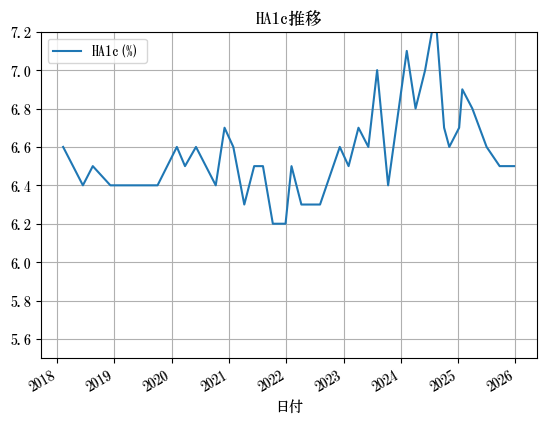

In [6]:
#グラフがインラインで表示される
%matplotlib inline 

df1.plot(title="HA1c推移",ylim=(5.5, 7.2), x="日付", grid=True)

In [ ]:
# font.familyのファイルを探す（必要なかった）
import matplotlib

print(matplotlib.matplotlib_fname())
print(matplotlib.get_configdir())
print(matplotlib.rcParams['font.family'])

In [ ]:
# 仕えるフォントを探す
import matplotlib
import matplotlib.font_manager as fm

fonts = fm.findSystemFonts()
for font in fonts:
    print(fm.FontProperties(fname=font).get_name())

In [9]:
pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------- ----- 7.1/8.1 MB 39.6 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 33.4 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 25.8 MB/s  0:00:00

   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- -------------------------- 2/6 [fonttools]
   ------------- ---------------